## Imports


In [1]:
import sys, torch, scprep
sys.path.append('../')
import warnings; warnings.filterwarnings('ignore')
from torch import optim
import torchvision; from torchvision import datasets, transforms
import numpy as np
import matplotlib; import matplotlib.pyplot as plt
import graphtools as gt
import networkx as nx
import scipy
from torch import nn
from sklearn.model_selection import train_test_split
from abc import abstractmethod
import scanpy as sc
from typing import List, Callable, Union, Any, TypeVar, Tuple
from torch.utils.data import DataLoader, TensorDataset

## Loading Datasets  

### MNIST Dataset

In [2]:
# --- Load MNIST ---
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
X = mnist.data.numpy().reshape(60000, -1)   # raw pixels (0–255)
y = mnist.targets.numpy()

# --- Balanced sample: 1000 per digit ---
idx = np.hstack([np.random.choice(np.where(y == d)[0], 1000, replace=False) for d in range(10)])
X_subset = X[idx]    # (10000, 784)

# --- Linear version (features × samples), range [0,1] ---
MNIST_v1 = torch.from_numpy((X_subset / 255).T).double()   

# --- Deep-learning version (samples × features), range [-1,1] ---
MNIST_v2 = torch.from_numpy(((X_subset / 255) * 2 - 1)).double()

# --- Diagnostics ---
print("MNIST_v1:", MNIST_v1.shape,
      "range:", (MNIST_v1.min().item(), MNIST_v1.max().item()))

print("MNIST_v2:    ", MNIST_v2.shape,
      "range:", (MNIST_v2.min().item(), MNIST_v2.max().item()))


MNIST_v1: torch.Size([784, 10000]) range: (0.0, 1.0)
MNIST_v2:     torch.Size([10000, 784]) range: (-1.0, 1.0)


### Sequence RNA dataset

In [4]:
"""Load from link"""
#Download data also available at https://www.kaggle.com/datasets/alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021
import os
import urllib.request

# Define the local filename
destination = "./data/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad"

# This is the direct link to the processed challenge dataset on Figshare
# (Maintained by the Open Problems team)
url = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE194122&format=file&file=GSE194122%5Fopenproblems%5Fneurips2021%5Fmultiome%5FBMMC%5Fprocessed%2Eh5ad%2Egz" 

print(f"Downloading dataset from original source (Figshare)...")

if not os.path.exists(destination):
    urllib.request.urlretrieve(url, destination)
    print("Download complete!")
else:
    print("File already exists.")

fn = './data/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad'
adata = sc.read(fn)    

KeyboardInterrupt: 

In [2]:
"""or load from local .zip"""
import zipfile
import tempfile

with zipfile.ZipFile("scRNA-seq.zip") as z:
    # find the .h5ad file
    h5ad_name = [f for f in z.namelist() if f.endswith(".h5ad")][0]

    # Extract to a temporary file
    with tempfile.NamedTemporaryFile(suffix=".h5ad", delete=False) as tmp:
        tmp.write(z.read(h5ad_name))
        tmp.flush()
        temp_path = tmp.name

# Load h5ad using disk access, not RAM
adata = sc.read_h5ad(temp_path, backed="r")



In [4]:
#there is 50 principal commponets in total, so no need to explicetly say it
adata.obsm['GEX_X_pca'].shape

(69249, 50)

In [30]:
# For now choose the subset, but we need to take whole dataset (its not that big)
adata_subset = sc.pp.subsample(adata, n_obs=10000, copy=True, random_state=42)

#labels
y = adata_subset.obs["cell_type"].to_numpy()

In [31]:
#@FABIAN, you might need to do smth about range here
sqRNA_v1 = torch.tensor(adata_subset.obsm['GEX_X_pca'], dtype=torch.float64).T
# --- Diagnostics ---
print("sqRNA_v1 shape:", sqRNA_v1.shape,
      "range:", (sqRNA_v1.min().item(), sqRNA_v1.max().item()))

sqRNA_v1 shape: torch.Size([50, 10000]) range: (-10.944077491760254, 26.201128005981445)


In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

sqRNA_v2 = scaler.fit_transform(adata_subset.obsm['GEX_X_pca'])           
sqRNA_v2 = torch.from_numpy(sqRNA_v2).float()   # convert to torch

print("sqRNA_v2 shape:", sqRNA_v2.shape,
      "range:", (sqRNA_v2.min().item(), sqRNA_v2.max().item()))



sqRNA_v2 shape: torch.Size([10000, 50]) range: (-1.0, 1.000000238418579)


In [23]:
print("sqRNA_v2:", sqRNA_v2.shape,
      "range:", (sqRNA_v2.min().item(), sqRNA_v2.max().item()))

sqRNA_v2: torch.Size([1000, 50]) range: (-1.0, 1.0000001192092896)


## Helper fuctions
general Functions:  
NMI  
Confidence  
...

In [8]:
from scipy.spatial.distance import pdist, squareform
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'




def ArchetypeConsistency(XC1, XC2, mSST):
    """
    Calculates the consistency between two sets of archetypes (XC1 and XC2).
    """
    # 1. Calculate Squared Euclidean Distance between all archetypes
    D = squareform(pdist(np.hstack((XC1, XC2)).T, 'euclidean'))**2
    D = D[:XC1.shape[1], XC1.shape[1]:]

    # 2. Greedy Matching to pair archetypes
    i = []
    j = []
    v = []
    K = XC1.shape[1]
    
    for k in range(K):
        # Find minimum distance in the matrix
        min_index = np.unravel_index(np.argmin(D, axis=None), D.shape)
        i.append(min_index[0])
        j.append(min_index[1])
        v.append(D[i[-1], j[-1]]) # Record the error (distance)
        
        # 'Remove' these from future consideration
        D[i[-1], :] = np.inf
        D[:, j[-1]] = np.inf

    # 3. Calculate Consistency Score (R^2-like metric)
    consistency = 1 - np.mean(v) / mSST

    # 4. Calculate Inter-Set Similarity Index (ISI)
    # Correlation between matched archetypes
    D2 = np.abs(np.corrcoef(np.hstack((XC1, XC2)).T))
    D2 = D2[:K, K:]
    ISI = 1 / (2 * K * (K - 1)) * (np.sum(D2 / np.max(D2, axis=1, keepdims=True) + D2 / np.max(D2, axis=0, keepdims=True)) - 2 * K)
    
    return consistency, ISI

def preprocess(X):
    """
    Mean-centers the data and computes the total variance (mSST).
    """
    meanX = np.mean(X, axis=0)
    X_centered = X - meanX
    # Mean Sum of Squares Total (Total Variance)
    mSST = np.sum(np.mean(X_centered**2, axis=0))
    return X_centered, mSST

def calcMI(z1,z2):
    eps = 10e-16
    P = z1@z2.T
    PXY = P/P.sum()
    PXPY = np.outer(np.expand_dims(PXY.sum(1), axis=0),np.expand_dims(PXY.sum(0), axis=1))
    ind = np.nonzero(PXY>0)
    MI = np.sum(PXY*np.log(eps+PXY/(eps+PXPY)))
    return MI
    
def calcNMI(z1,z2):
    NMI=(2*calcMI(z1,z2))/(calcMI(z1,z1)+calcMI(z2,z2))
    #NMI = NMI.reshape((z1.shape[0], z1.shape[0]))
    
    return NMI

def plot_loss_arc(L,n_arc_list,i,color,model, dataset, savedir = None):


    fig, ax = plt.subplots(figsize=(15, 5),layout='constrained')

    ax.errorbar(n_arc_list,np.mean(L,axis=1),yerr=np.std(L,axis=1),c=color,label=f'{model} - {dataset}')

    ##
    # ax.set_xticks(n_arc_list,fontsize=25)
    ax.set_xticks(n_arc_list)       # Set the tick positions
    ax.tick_params(axis='x') # Set the font size separately
    ##

    ax.set_xlabel('Number of Archetypes',fontsize=30)
    ax.set_ylabel('Loss',fontsize=30)

    plt.legend(fontsize=30)

    plt.yticks(fontsize=25)
    plt.xticks(fontsize=25)    
    #plt.title(f'{model} - {dataset}',fontsize=30)

    if savedir is not None:
        plt.savefig(savedir+f"/loss_layer_"+str(i)+".png")
        plt.close()
    else:
        plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_nmi_stability(NMI,n_arc_list,model,dataset, colors, savedir = None):
    
    
    df = pd.DataFrame(NMI.T)
    df['Method'] = f'Model {model}'


    df = df.melt(id_vars='Method', var_name='Archetypes', value_name='NMI')
    fig, ax = plt.subplots(1,1,figsize = (15,5), layout='constrained')

    ax = sns.boxplot(x='Archetypes', y="NMI", hue="Method", showmeans=True, data=df,palette=colors,meanprops={"marker": "s", "markerfacecolor": "white", "markeredgecolor": "black"})
    ax.xaxis.grid(True, which='major')
    [ax.axvline(x+.5,color='k') for x in ax.get_xticks()]
    plt.xticks(np.arange(len(n_arc_list)),n_arc_list,fontsize=25)
    plt.yticks(fontsize=25)    
    ax.set_xlabel('Number of archetypes', fontsize=30)
    ax.set_ylabel('NMI', fontsize=30)

    ax.set_ylim([0,1.05])
    plt.legend(fontsize=30,loc = 'lower right')
    plt.title(f'{model} - {dataset}',fontsize=30)
    
    if savedir is not None:
        plt.savefig(savedir+f"/NMI_model_"+str(model)+"dataset_"+str(dataset)+".png")
        plt.close()
    else:
        plt.show()

## Linear AA Implementation

In [3]:
from LinearAA.AALS import AALS
import torch
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
colors = ["#EF476F",  "#06D6A0", "#FFD166", "#073B4C", "#118AB2", "#FF6B6B", "#C8A2C8"]

In [6]:
# Show small test
# running linear AA on mini subset, 4 times for each archetype, we run it multiple times for each archetype to see stability (NMI)
test_Linear_X = MNIST_v1[:, :50]
n_runs = 4
n_arc_list = [f for f in range(2,15)]
Losses = np.zeros((len(n_arc_list),n_runs))
Ss = np.zeros((len(n_arc_list),n_runs),dtype=object)

for n in tqdm(n_arc_list):
    for i in range(n_runs):

        C,S,L,EV = AALS(test_Linear_X, n)
        Losses[n_arc_list.index(n),i] = L[-1]
        Ss[n_arc_list.index(n),i] = S
        

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:12<00:00,  1.07it/s]


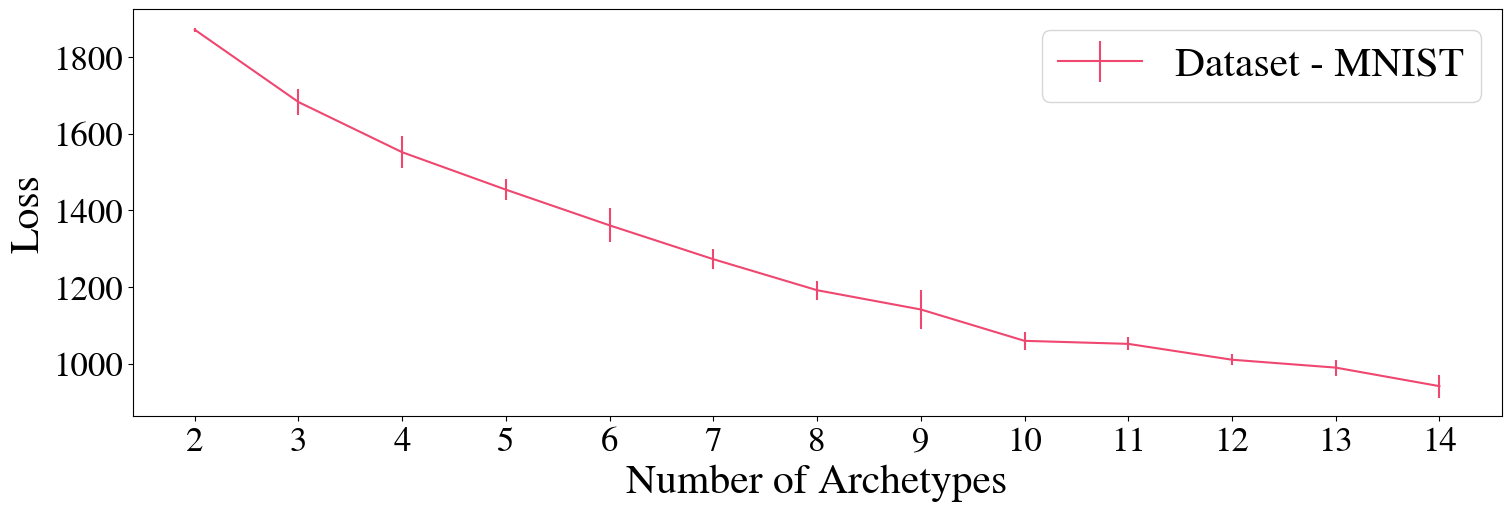

In [9]:
plot_loss_arc(Losses,n_arc_list,i,colors[0],'Dataset', 'MNIST', savedir = None)

100%|██████████| 13/13 [00:00<00:00, 552.62it/s]
C:\Users\fabia\AppData\Local\Temp\ipykernel_12252\2142883590.py:113: UserWarning: The palette list has more values (7) than needed (1), which may not be intended.
  ax = sns.boxplot(x='Archetypes', y="NMI", hue="Method", showmeans=True, data=df,palette=colors,meanprops={"marker": "s", "markerfacecolor": "white", "markeredgecolor": "black"})


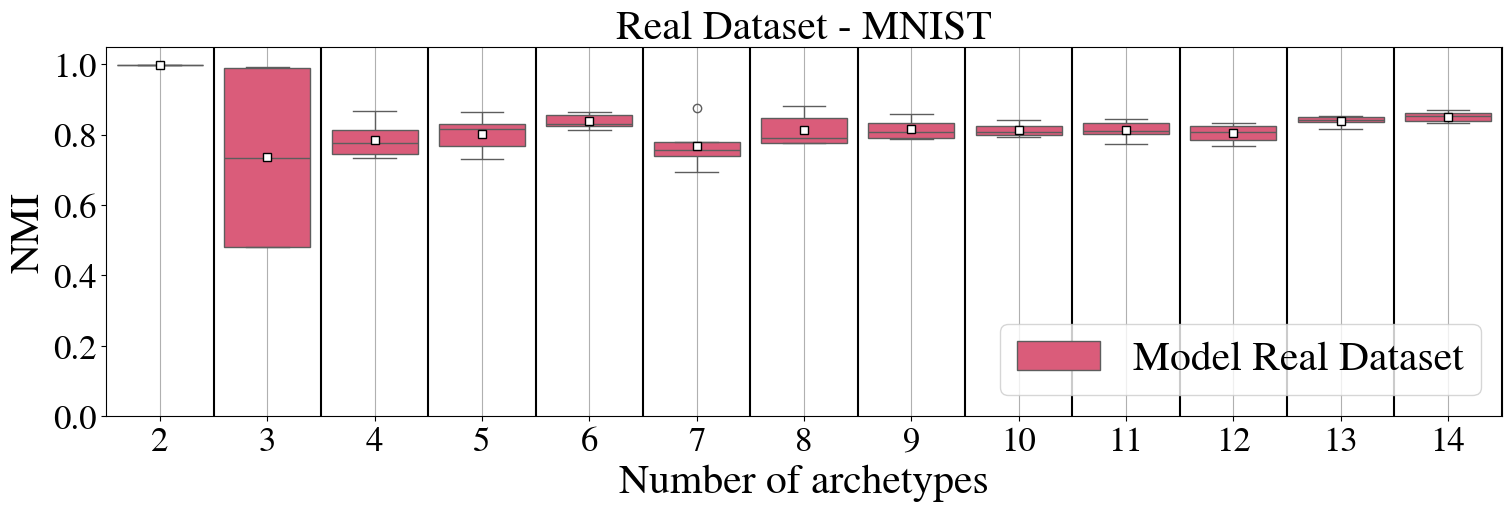

In [8]:
test = itertools.combinations(range(n_runs), 2)
t = list(test)
calcIDX = np.array(t)

NMI = np.zeros((len(n_arc_list),len(calcIDX)))

for n in tqdm(n_arc_list):
    for j in range(len(calcIDX)):

        S1 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,0]])
        S2 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,1]])


        NMI[n_arc_list.index(n),j] = calcNMI(S1,S2)

plot_nmi_stability(NMI,n_arc_list, 'Real Dataset','MNIST',colors)

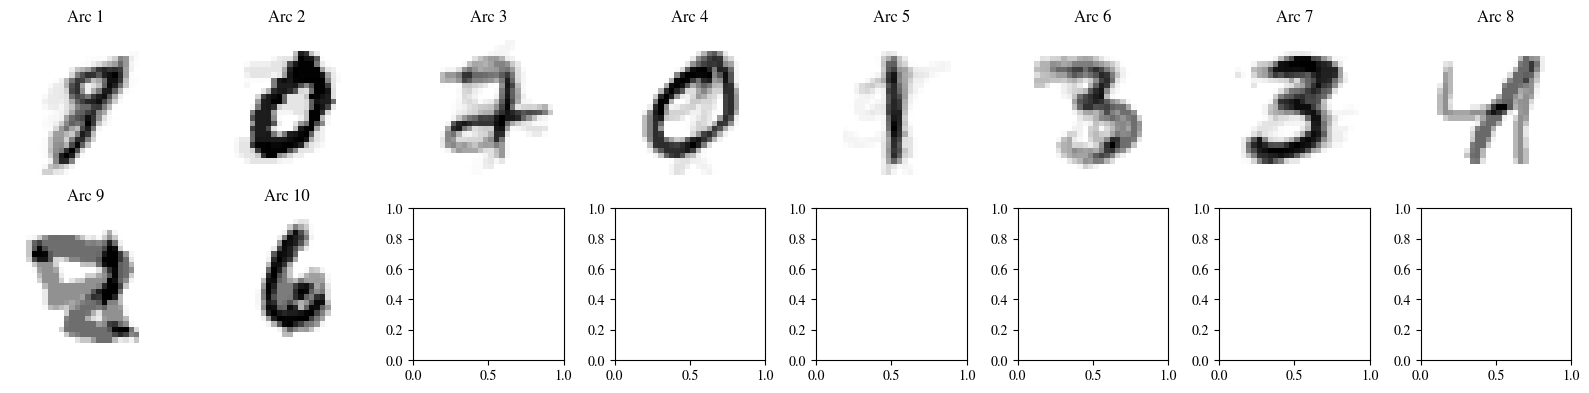

In [9]:
n_archetypes = 10
C_final, S_final, L_final, EV_final = AALS(test_Linear_X, n_archetypes)

# 1. Calculate the actual Archetypes (Z = X * C)
# Ensure both are the same type (likely Torch tensors based on your output)
if isinstance(C_final, np.ndarray):
    C_final = torch.from_numpy(C_final)
if isinstance(test_Linear_X, np.ndarray):
    test_Linear_X = torch.from_numpy(test_Linear_X)

# Matrix Multiplication: (784x100) @ (100x16) -> (784x16)
archetypes_matrix = torch.matmul(test_Linear_X, C_final) 
# 2. Visualize
n_archetypes = archetypes_matrix.shape[1] # Should be 16
rows = int(n_archetypes // 8) + 1  # Adjust grid (2x8 = 16)
cols = 8 # Adjust grid (2x8 = 16)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2))
axes = axes.flatten()

for i in range(n_archetypes):
    # Get the i-th archetype (all 784 pixels)
    arc_vector = archetypes_matrix[:, i]
    
    # Reshape to 28x28 image
    arc_img = arc_vector.reshape(28, 28).detach().numpy() # detach if it requires grad
    
    axes[i].imshow(arc_img, cmap='gray_r')
    axes[i].set_title(f"Arc {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## AAnet implementation

In [24]:
def train_epoch(model, data_loader, optimizer, epoch, gamma_reconstruction=1.0, gamma_archetypal=1.0, gamma_extrema=1.0):
    loss = 0
    reconstruction_loss = 0
    archetypal_loss = 0
    extrema_loss = 0

    for idx, data in enumerate(data_loader):
        
        # if input is list, then data_loader contains features and target
        # assume first input is features based on data_loader structure
        if isinstance(data, list):
            batch_features = data[0]
        else:
            batch_features = data
        
        # if there are extrema, add diffusion extrema to beginning of each batch
        # first n_archetypes samples are used in extrema loss
        if model.diffusion_extrema is not None:
            batch_features = torch.cat((model.diffusion_extrema.view(-1, model.input_shape),
                                    batch_features.view(-1, model.input_shape)), 0)
            
        # reshape mini-batch data to [N, input_shape] matrix
        batch_features = batch_features.view(-1, model.input_shape)
        
        # load it to the active device
        batch_features = batch_features.to(model.device)

        # reset the gradients back to zero
        # PyTorch accumulates gradients on subsequent backward passes
        optimizer.zero_grad()

        # compute reconstructions
        output, _in, archetypal_embedding = model(batch_features.float())

        # compute training reconstruction loss
        curr_reconstruction_loss = torch.mean((output - batch_features)**2)
        reconstruction_loss += curr_reconstruction_loss

        # compute training archetypal loss
        curr_archetypal_loss = model.calc_archetypal_loss(archetypal_embedding)
        archetypal_loss += curr_archetypal_loss
        
        # compute training diffusion extrema loss
        if model.diffusion_extrema is not None:
            curr_extrema_loss = model.calc_diffusion_extrema_loss(archetypal_embedding)
            extrema_loss += curr_extrema_loss
        else:
            curr_extrema_loss = 0
            extrema_loss = 0
            
        # extrema penalization decreases over batches and epochs
        # this enables AAnet to learn the correct archetypes if the diffusion extrema are not close
        train_loss = gamma_reconstruction * curr_reconstruction_loss + \
                     gamma_archetypal * curr_archetypal_loss + \
                     gamma_extrema /(epoch * len(data_loader) + (idx+1)) * curr_extrema_loss

        # compute accumulated gradients
        train_loss.backward()

        # perform parameter update based on current gradients
        optimizer.step()

        # add the mini-batch training loss to epoch loss
        loss += train_loss.item()

    # compute the epoch training loss
    loss = loss / len(data_loader)
    reconstruction_loss = reconstruction_loss / len(data_loader)
    archetypal_loss = archetypal_loss / len(data_loader)
    return loss, reconstruction_loss, archetypal_loss

In [25]:
class AAnet_vanilla(nn.Module):
    def __init__(
        self,
        input_shape,
        n_archetypes=4,
        noise=0,
        layer_widths=[128, 128],
        activation_out="tanh",
        simplex_scale=1,
        device=None,
        diffusion_extrema=None,
        **kwargs
    ):
        super().__init__()

        self.input_shape = input_shape
        self.n_archetypes = n_archetypes
        self.noise = noise
        self.layer_widths = layer_widths
        self.activation_out = activation_out
        self.simplex_scale = simplex_scale
        self.diffusion_extrema = diffusion_extrema
        
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        # ---------------------------
        # Encoder network
        # ---------------------------
        self.encoder_layers = nn.ModuleList()
        for i, width in enumerate(layer_widths):
            in_features = input_shape if i == 0 else layer_widths[i - 1]
            self.encoder_layers.append(nn.Linear(in_features, width))

        # Last encoder layer → latent dims = n_archetypes - 1
        self.encoder_layers.append(nn.Linear(layer_widths[-1], n_archetypes - 1))

        # ---------------------------
        # Decoder network
        # ---------------------------
        self.decoder_layers = nn.ModuleList()
        decoder_widths = layer_widths[::-1]

        for i, width in enumerate(decoder_widths):
            in_features = n_archetypes - 1 if i == 0 else decoder_widths[i - 1]
            self.decoder_layers.append(nn.Linear(in_features, width))

        # Last decoder layer → reconstruct input
        self.decoder_layers.append(
            nn.Linear(decoder_widths[-1], input_shape)
        )

        # Precompute archetypal simplex
        self.archetypal_simplex = self.get_n_simplex(n_archetypes, simplex_scale)

        self.to(self.device)

    # ============================================================
    # Utility functions (migrated from BaseAAnet)
    # ============================================================

    def get_n_simplex(self, n=2, scale=1):
        """Returns an n-simplex centered at the origin."""
        nth = (1/(n-1)*(1-np.sqrt(n))) * np.ones(n-1)
        D = np.vstack([np.eye(n-1), nth]) * scale
        return torch.tensor(D - np.mean(D, axis=0), dtype=torch.float, device=self.device)

    def euclidean_to_barycentric(self, X):
        """Convert Euclidean → barycentric coordinates."""
        simplex = self.archetypal_simplex

        T = torch.zeros((X.shape[1], X.shape[1])).to(self.device)
        for i in range(X.shape[1]):
            for j in range(X.shape[1]):
                T[i, j] = simplex[i, j] - simplex[-1, j]

        T_inv = torch.inverse(T).float().to(self.device)

        X_bary = torch.einsum("ij,bj->bi", T_inv, X - simplex[-1])
        X_bary = torch.cat(
            [X_bary, (1 - torch.sum(X_bary, dim=1, keepdim=True))],
            dim=1
        )
        return X_bary

    def dist_to_simplex(self, X_bary):
        """Distance penalty for barycentric coords outside simplex."""
        return torch.sum(torch.clamp(-X_bary, min=0), dim=1)

    def calc_archetypal_loss(self, archetypal_embedding):
        """Archetypal loss = MSE of distance to simplex."""
        X_bary = self.euclidean_to_barycentric(archetypal_embedding)
        return torch.mean(self.dist_to_simplex(X_bary) ** 2)

    def calc_diffusion_extrema_loss(self, archetypal_embedding):
        """MSE loss between diffusion extrema and simplex vertices."""
        X_bary = self.euclidean_to_barycentric(archetypal_embedding)
        return torch.mean(
            (X_bary[:self.n_archetypes, :] -
             torch.eye(self.n_archetypes, device=self.device)) ** 2
        )

    # ============================================================
    # Encoder / Decoder
    # ============================================================

    def encode(self, x):
        for layer in self.encoder_layers[:-1]:
            x = torch.relu(layer(x))
        return self.encoder_layers[-1](x)  # no activation

    def decode(self, z):
        for layer in self.decoder_layers[:-1]:
            z = torch.relu(layer(z))
        return self.decoder_layers[-1](z)  # no activation

    # ============================================================
    # Forward
    # ============================================================

    def forward(self, x) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
            recons → reconstructed data
            x → original input
            archetypal_embedding → latent embedding
        """
        z = self.encode(x)
        archetypal_embedding = z.clone()

        if self.noise > 0:
            z = z + torch.normal(0., self.noise, size=z.shape).to(self.device)

        recons = self.decode(z)

        return recons, x, archetypal_embedding


In [27]:
#MNIST
N = len(MNIST_v2)
perm = torch.randperm(N)

train_end = int(0.7 * N)
val_end   = int(0.85 * N)

X_train = MNIST_v2[perm[:train_end]].float()
X_val   = MNIST_v2[perm[train_end:val_end]].float()
X_test  = MNIST_v2[perm[val_end:]].float()

train_loader = DataLoader(TensorDataset(X_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=256, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test),  batch_size=256, shuffle=False)

device = torch.device("cpu")


# ----------------------------------------------------------
# Helper: evaluate reconstruction loss on validation or test
# ----------------------------------------------------------
def evaluate_recon(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for batch, in loader:
            batch = batch.to(device)

            # FIX: model returns (recon, x, archetype_embedding)
            recon, *_ = model(batch)

            mse = ((recon - batch)**2).mean().item()
            total += mse * len(batch)

    return total / len(loader.dataset)


# ----------------------------------------------------------
# 3. Loop over archetype counts and store VAL losses
# ----------------------------------------------------------
reconstruction_losses = {}
best_k = None
best_val_loss = float("inf")

for N_ARCHETYPES in range(3, 20):

    print(f"\n==== Testing {N_ARCHETYPES} archetypes ====")

    model = AAnet_vanilla(
        noise=0.05,
        layer_widths=[256, 128],
        n_archetypes=N_ARCHETYPES,
        input_shape=MNIST_v2.shape[1],
        device=device,
        diffusion_extrema=None
    )

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    EPOCHS = 20
    for epoch in range(1, EPOCHS + 1):

        loss, r_loss, a_loss = train_epoch(
            model, train_loader, optimizer,
            epoch=epoch,
            gamma_reconstruction=1.0,
            gamma_archetypal=1.0,
            gamma_extrema=1.0
        )

        val_recon = evaluate_recon(model, val_loader)

        print(f"Epoch {epoch}: train_recon={r_loss:.5f}  val_recon={val_recon:.5f}")

    reconstruction_losses[N_ARCHETYPES] = val_recon

    if val_recon < best_val_loss:
        best_val_loss = val_recon
        best_k = N_ARCHETYPES


# ----------------------------------------------------------
# 4. Select best k and retrain on train+val
# ----------------------------------------------------------
print(f"\nBest number of archetypes based on validation: k={best_k}")

X_train_final = torch.cat([X_train, X_val], dim=0)
final_loader = DataLoader(TensorDataset(X_train_final), batch_size=256, shuffle=True)

model_final = AAnet_vanilla(
    noise=0.05,
    layer_widths=[256, 128],
    n_archetypes=best_k,
    input_shape=MNIST_v2.shape[1],
    device=device,
    diffusion_extrema=None
)

optimizer = optim.Adam(model_final.parameters(), lr=1e-3)


for epoch in range(1, EPOCHS + 1):
    loss, r_loss, a_loss = train_epoch(
        model_final, final_loader, optimizer,
        epoch=epoch,
        gamma_reconstruction=1.0,
        gamma_archetypal=1.0,
        gamma_extrema=1.0
    )


# ----------------------------------------------------------
# 5. Final test evaluation
# ----------------------------------------------------------
test_recon = evaluate_recon(model_final, test_loader)
print(f"\nFinal TEST reconstruction loss (k={best_k}): {test_recon:.6f}")

NameError: name 'MNIST_v2' is not defined

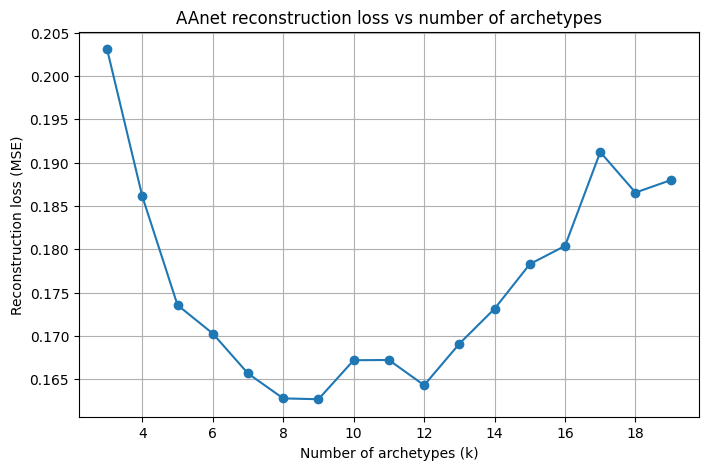

In [14]:
ks = sorted(reconstruction_losses.keys())
losses = [reconstruction_losses[k] for k in ks]

plt.figure(figsize=(8, 5))
plt.plot(ks, losses, marker="o")
plt.xlabel("Number of archetypes (k)")
plt.ylabel("Reconstruction loss (MSE)")
plt.title("AAnet reconstruction loss vs number of archetypes")
plt.grid(True)
plt.show()

In [33]:
#scRNA-seq
N = len(sqRNA_v2)
perm = torch.randperm(N)

train_end = int(0.7 * N)
val_end   = int(0.85 * N)

X_train = sqRNA_v2[perm[:train_end]].float()
X_val   = sqRNA_v2[perm[train_end:val_end]].float()
X_test  = sqRNA_v2[perm[val_end:]].float()

train_loader = DataLoader(TensorDataset(X_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=256, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test),  batch_size=256, shuffle=False)

device = torch.device("cpu")


# ----------------------------------------------------------
# Helper: evaluate reconstruction loss on validation or test
# ----------------------------------------------------------
def evaluate_recon(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for batch, in loader:
            batch = batch.to(device)

            # FIX: model returns (recon, x, archetype_embedding)
            recon, *_ = model(batch)

            mse = ((recon - batch)**2).mean().item()
            total += mse * len(batch)

    return total / len(loader.dataset)


# ----------------------------------------------------------
# 3. Loop over archetype counts and store VAL losses
# ----------------------------------------------------------
reconstruction_losses = {}
best_k = None
best_val_loss = float("inf")

for N_ARCHETYPES in range(3, 20):

    print(f"\n==== Testing {N_ARCHETYPES} archetypes ====")

    model = AAnet_vanilla(
        noise=0.05,
        layer_widths=[256, 128],
        n_archetypes=N_ARCHETYPES,
        input_shape=sqRNA_v2.shape[1],
        device=device,
        diffusion_extrema=None
    )

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    EPOCHS = 20
    for epoch in range(1, EPOCHS + 1):

        loss, r_loss, a_loss = train_epoch(
            model, train_loader, optimizer,
            epoch=epoch,
            gamma_reconstruction=1.0,
            gamma_archetypal=1.0,
            gamma_extrema=1.0
        )

        val_recon = evaluate_recon(model, val_loader)

        print(f"Epoch {epoch}: train_recon={r_loss:.5f}  val_recon={val_recon:.5f}")

    reconstruction_losses[N_ARCHETYPES] = val_recon

    if val_recon < best_val_loss:
        best_val_loss = val_recon
        best_k = N_ARCHETYPES


# ----------------------------------------------------------
# 4. Select best k and retrain on train+val
# ----------------------------------------------------------
print(f"\nBest number of archetypes based on validation: k={best_k}")

X_train_final = torch.cat([X_train, X_val], dim=0)
final_loader = DataLoader(TensorDataset(X_train_final), batch_size=256, shuffle=True)

model_final = AAnet_vanilla(
    noise=0.05,
    layer_widths=[256, 128],
    n_archetypes=best_k,
    input_shape=sqRNA_v2.shape[1],
    device=device,
    diffusion_extrema=None
)

optimizer = optim.Adam(model_final.parameters(), lr=1e-3)


for epoch in range(1, EPOCHS + 1):
    loss, r_loss, a_loss = train_epoch(
        model_final, final_loader, optimizer,
        epoch=epoch,
        gamma_reconstruction=1.0,
        gamma_archetypal=1.0,
        gamma_extrema=1.0
    )


# ----------------------------------------------------------
# 5. Final test evaluation
# ----------------------------------------------------------
test_recon = evaluate_recon(model_final, test_loader)
print(f"\nFinal TEST reconstruction loss (k={best_k}): {test_recon:.6f}")


==== Testing 3 archetypes ====
Epoch 1: train_recon=0.03744  val_recon=0.03006
Epoch 2: train_recon=0.02971  val_recon=0.02923
Epoch 3: train_recon=0.02924  val_recon=0.02886
Epoch 4: train_recon=0.02872  val_recon=0.02820
Epoch 5: train_recon=0.02802  val_recon=0.02752
Epoch 6: train_recon=0.02750  val_recon=0.02738
Epoch 7: train_recon=0.02736  val_recon=0.02731
Epoch 8: train_recon=0.02723  val_recon=0.02725
Epoch 9: train_recon=0.02710  val_recon=0.02721
Epoch 10: train_recon=0.02710  val_recon=0.02717
Epoch 11: train_recon=0.02695  val_recon=0.02707
Epoch 12: train_recon=0.02683  val_recon=0.02702
Epoch 13: train_recon=0.02680  val_recon=0.02698
Epoch 14: train_recon=0.02667  val_recon=0.02688
Epoch 15: train_recon=0.02662  val_recon=0.02681
Epoch 16: train_recon=0.02655  val_recon=0.02680
Epoch 17: train_recon=0.02650  val_recon=0.02677
Epoch 18: train_recon=0.02651  val_recon=0.02671
Epoch 19: train_recon=0.02642  val_recon=0.02671
Epoch 20: train_recon=0.02643  val_recon=0.026

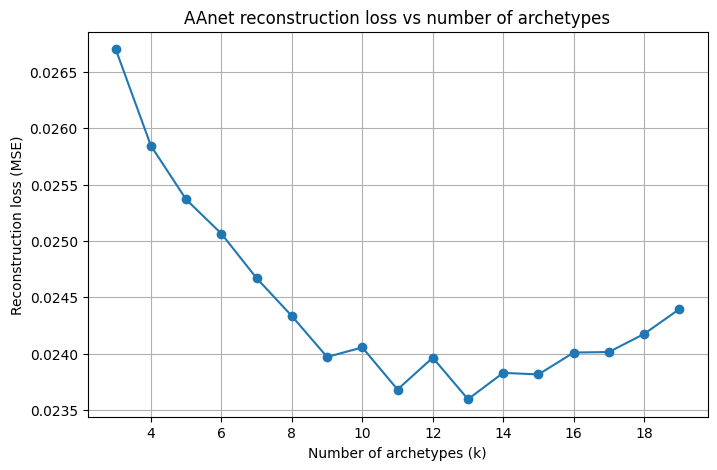

In [34]:
ks = sorted(reconstruction_losses.keys())
losses = [reconstruction_losses[k] for k in ks]

plt.figure(figsize=(8, 5))
plt.plot(ks, losses, marker="o")
plt.xlabel("Number of archetypes (k)")
plt.ylabel("Reconstruction loss (MSE)")
plt.title("AAnet reconstruction loss vs number of archetypes")
plt.grid(True)
plt.show()

## Midaa